# 5. Inclination estimation and Fourier-domain compression

## Estimating the inclination

The star's inclination is usually unknown, and getting it wrong warps the
recovered map. jittermap estimates it by refitting the surface at each
trial inclination and scoring the fit, the *profile objective* $J(\beta)$.
Scanning $J(\beta)$ shows how much each data type knows about the tilt.

The answer depends on what we assume about the surface, and it can only
be judged against noise: a tilt is identifiable when the objective rises
meaningfully above the noise floor away from the truth, not merely when
a minimum exists at scales no instrument could see. We therefore observe
at a per-channel signal-to-noise ratio of 100 throughout, and walk
through three assumptions from weakest to strongest: a completely free
surface with no prior, a free surface with the GMRF smoothness prior,
and a surface known to consist of circular spots.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jittermap as jm
from jittermap.plotting.render import build_projection_grid, render_surface_fast
from jittermap.plotting.panels import render_panel, normalize_map
GRID = build_projection_grid(n_grid=200)
X, Y, Z, THETA, PHI, MASK = GRID

def show_star(ax, coeffs, l_max, beta, title="", t=0.0):
    m = render_surface_fast(coeffs, l_max, beta, THETA, PHI, MASK, X, Y, Z, t=t)
    render_panel(ax, normalize_map(m), title, beta)
    ax.set_xticks([]); ax.set_yticks([])


light curve only: min 0.74 at beta = 0.635, max 0.92


astrometry only: min 0.61 at beta = 0.559, max 1.03


joint          : min 0.71 at beta = 0.559, max 1.03


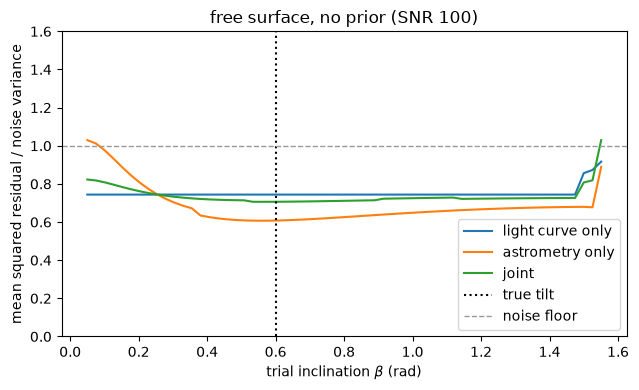

In [2]:
from jittermap.inference.inclination import profile_objective

L, N = 10, 100
INC_TRUE = 0.6
SNR = 100
times = np.linspace(0, 2*np.pi, N, endpoint=False)
star = jm.multispot_surface([(30, 315, 18.0), (-15, 30, 13.0)], L,
                            texture_amplitude=0.002, texture_seed=3)
fm = jm.ForwardModel(times, l_max=L)
clean = fm.observe(star, inclination=INC_TRUE, channels="xyp", stacked=False)

rng = np.random.default_rng(7)
sigma = {c: clean[c].std() / SNR for c in "xyp"}
data = {c: clean[c] + rng.normal(0, sigma[c], N) for c in "xyp"}

betas = np.linspace(0.05, np.pi/2 - 0.02, 60)

def noise_floor(ch):
    """Mean noise variance of the stacked channels."""
    return np.mean([sigma[c]**2 for c in ch])

def scan(ch, lam):
    """Profile objective per sample, in units of the noise variance."""
    y = np.concatenate([data[c] for c in ch])
    return np.array([profile_objective(b, y, ch, L, fm.kernels, fm._precomp,
                                       lam=lam) / y.size
                     for b in betas]) / noise_floor(ch)

plt.figure(figsize=(6.5, 4))
for ch, label in [("p", "light curve only"), ("xy", "astrometry only"),
                  ("xyp", "joint")]:
    J = scan(ch, lam=0)
    plt.plot(betas, J, label=label)
    print(f"{label:15s}: min {J.min():.2f} at beta = {betas[np.argmin(J)]:.3f}, "
          f"max {J.max():.2f}")
plt.axvline(INC_TRUE, color="k", ls=":", label="true tilt")
plt.axhline(1.0, color="0.6", lw=1, ls="--", label="noise floor")
plt.ylim(0, 1.6)
plt.xlabel("trial inclination $\\beta$ (rad)")
plt.ylabel("mean squared residual / noise variance")
plt.title("free surface, no prior (SNR 100)")
plt.legend(); plt.tight_layout()

Nothing rises meaningfully above the noise floor, for any channel. The
free surface has $(L+1)^2 = 121$ modes against 100 or 200 samples, so at
every trial tilt the fit can contort the surface to absorb the signal
and much of the noise; what remains varies by tens of percent of the
noise variance across the scan, and the location of its minimum carries
no information.

Running the same scan on noiseless data does produce an apparent
astrometric minimum at the truth, but at mean squared residuals of
$10^{-7}$ and below, where model mismatch competes with floating-point
error. The column spaces of the free-surface designs barely move with
$\beta$ (the photometric one, spanned by the same $2L+1$ rotation
harmonics at every tilt, does not move at all), so those tiny residuals
are not a usable measurement: any realistic noise buries them, as the
figure shows. With an unconstrained surface, no channel identifies the
inclination.

## What the prior does

The GMRF prior scores the plausibility of the surface each tilt needs.
Reproducing the data at a wrong tilt requires a rougher, more contorted
surface, and the penalty term exposes that even where the residual alone
is blind:

light curve only lambda = 0.0002: minimum at beta = 0.381


light curve only lambda =   0.02: minimum at beta = 0.457


astrometry only lambda = 0.0002: minimum at beta = 0.482


astrometry only lambda =   0.02: minimum at beta = 0.381


joint           lambda = 0.0002: minimum at beta = 0.584


joint           lambda =   0.02: minimum at beta = 0.584


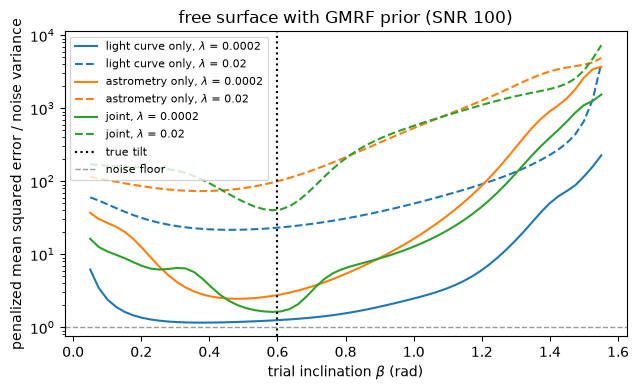

In [3]:
plt.figure(figsize=(6.5, 4))
colors = {"p": "C0", "xy": "C1", "xyp": "C2"}
for ch, label in [("p", "light curve only"), ("xy", "astrometry only"),
                  ("xyp", "joint")]:
    for lam, ls in [(2e-4, "-"), (2e-2, "--")]:
        J = scan(ch, lam)
        plt.semilogy(betas, J, ls, color=colors[ch],
                     label=f"{label}, $\\lambda$ = {lam:g}")
        print(f"{label:15s} lambda = {lam:6g}: minimum at "
              f"beta = {betas[np.argmin(J)]:.3f}")
plt.axvline(INC_TRUE, color="k", ls=":", label="true tilt")
plt.axhline(1.0, color="0.6", lw=1, ls="--", label="noise floor")
plt.xlabel("trial inclination $\\beta$ (rad)")
plt.ylabel("penalized mean squared error / noise variance")
plt.title("free surface with GMRF prior (SNR 100)")
plt.legend(fontsize=8); plt.tight_layout()

With the prior the objective finally has structure, and against the
noise floor the contrasts are real: two to three orders of magnitude,
far beyond anything numerics can fake.

- **Light curve.** A genuine basin appears, but its minimum sits near
  $\beta \approx 0.4$, well away from the truth: the photometric
  inclination ambiguity is a property of the channel, and the prior
  reveals it rather than removes it.
- **Astrometry.** A deep basin whose minimum lands near, but not
  exactly on, the truth: the penalty trades data fidelity for
  smoothness, and it pays that trade slightly differently at different
  tilts.
- **Joint.** A single stable minimum essentially at the truth, at both
  prior strengths. This combination, free surface plus GMRF prior plus
  both data types, is what `reconstruct` uses:

In [4]:
for ch, label in [("p", "light curve"), ("xy", "astrometry"), ("xyp", "joint")]:
    res = jm.reconstruct({c: data[c] for c in ch}, times, L, channels=ch,
                         lam=2e-4, model=fm)
    print(f"{label:11s}: estimated tilt {res.inclination:.3f} rad "
          f"(true {INC_TRUE})")

light curve: estimated tilt 0.377 rad (true 0.6)
astrometry : estimated tilt 0.482 rad (true 0.6)


joint      : estimated tilt 0.587 rad (true 0.6)


## A spots-only surface model

The strongest assumption is parametric: the surface is known to be a
small number of circular spots, and we fit only their latitudes,
longitudes and radii. This is the regime where the familiar claim
"astrometry pins down the inclination, photometry does not" is cleanest.
At each trial tilt we refit the six spot parameters on the same noisy
data by direct optimization, with a restart to guard against local
minima (this cell takes a minute or so):

light curve only: min   1.1 at beta = 0.518


astrometry only: min   8.7 at beta = 0.601


joint          : min   5.4 at beta = 0.601


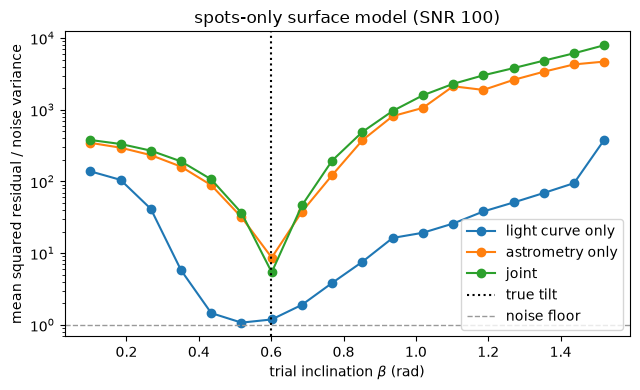

In [5]:
from scipy.optimize import minimize
from jittermap.forward.design import design_matrix_vandermonde

p_true = np.array([30, 315, 18.0, -15, 30, 13.0])

def spot_mse(params, D, y):
    s = jm.multispot_surface([(params[0], params[1], params[2]),
                              (params[3], params[4], params[5])], L)
    r = y - (D @ s).real
    return float(np.mean(r**2))

def profile_spot(beta, ch):
    D = np.vstack([design_matrix_vandermonde(L, beta, fm.kernels[c],
                                             *fm._precomp) for c in ch])
    y = np.concatenate([data[c] for c in ch])
    inits = [p_true, p_true * np.array([-1, 1, 1, -1, 1, 1])]
    return min(minimize(spot_mse, p0, args=(D, y), method="Nelder-Mead",
                        options={"maxiter": 500,
                                 "fatol": 0.01 * noise_floor(ch),
                                 "xatol": 0.02}).fun
               for p0 in inits)

betas_s = np.linspace(0.1, np.pi/2 - 0.05, 18)
plt.figure(figsize=(6.5, 4))
for ch, label in [("p", "light curve only"), ("xy", "astrometry only"),
                  ("xyp", "joint")]:
    Js = np.array([profile_spot(b, ch) for b in betas_s]) / noise_floor(ch)
    plt.semilogy(betas_s, Js, "o-", label=label)
    print(f"{label:15s}: min {Js.min():5.1f} at beta = "
          f"{betas_s[np.argmin(Js)]:.3f}")
plt.axvline(INC_TRUE, color="k", ls=":", label="true tilt")
plt.axhline(1.0, color="0.6", lw=1, ls="--", label="noise floor")
plt.xlabel("trial inclination $\\beta$ (rad)")
plt.ylabel("mean squared residual / noise variance")
plt.title("spots-only surface model (SNR 100)")
plt.legend(); plt.tight_layout()

The three curves now say precisely what the words claim. The astrometric
objective minimizes exactly at the true tilt, with contrast of roughly
five hundred to one across the scan. The photometric minimum is
displaced to $\beta \approx 0.52$, and, more telling, it reaches the
noise floor there: a wrong-tilt spot model is *fully consistent* with
the noisy light curve, so no amount of data of this kind rescues
photometry alone. The joint objective minimizes at the truth with the
largest contrast of all. (The astrometric minimum sits a little above
the noise floor because the true surface carries small-scale texture
that the pure two-spot model cannot represent.)

Taken together, the three regimes give the honest version of the
argument. With a completely unconstrained surface and real noise, no
channel identifies the tilt. The GMRF prior restores identifiability
but cannot cure the photometric ambiguity. And the more we are entitled
to assume about the surface, the more decisively astrometry converts
that assumption into an inclination measurement.

## The signal is a frequency comb

One practical bonus of the model: for uniform sampling over a rotation,
the signals contain only the harmonics $m\omega$ of the rotation rate,
$m = -L..L$. So $N$ time samples compress **losslessly** into just $2L+1$
Fourier coefficients — handy for storing and fitting long campaigns:

compressed data still fits the model exactly: True
100 time samples -> 21 numbers, nothing lost


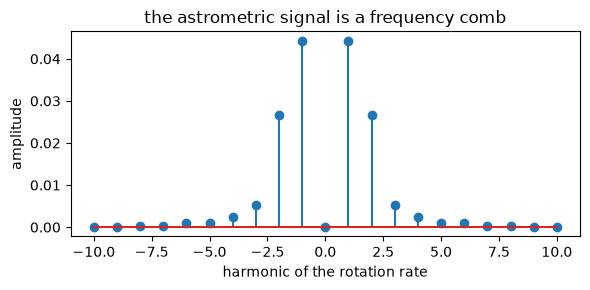

In [6]:
from jittermap.forward.fourier import compress, fourier_design_matrix
from jittermap.forward.kernels import compute_A_lm

A_x, _ = compute_A_lm(L)
y_x = fm.observe(star, INC_TRUE, channels="x")
f = compress(y_x, L)
F = fourier_design_matrix(L, INC_TRUE, A_x)
print("compressed data still fits the model exactly:",
      np.allclose(f, F @ star, atol=1e-12))
print(f"{N} time samples -> {2*L+1} numbers, nothing lost")

m_vals = np.arange(-L, L+1)
plt.figure(figsize=(6, 3))
plt.stem(m_vals, np.abs(f))
plt.xlabel("harmonic of the rotation rate")
plt.ylabel("amplitude")
plt.title("the astrometric signal is a frequency comb")
plt.tight_layout()